### ResNet의 확장 모델 - DenseNet

DenseNet

덴스블록 함수
배치정규화 하고 렐루함수를 씌운다 합성곱 필터를 적용하고 3x3필터 32개로 실제 특징을 추출 padding은 same으로 입력
이전 입력과 새로만든 특징을 쌓는 방식으로 사용

트랜지션 블록함수 
그다음 데이터를 또 배치정규화 렐루함수씌우고 무거워 지는걸 방지하기 위해 채널수를 절반으로 줄인다.

224,3,3짜리 이미지를 받아오고
맵의 가장자리를 0값을 채워넣고 출력크기를 절반으로 줄인다 배치정규화후 렐루함수 씌우고 가장자리 1칸씩 0으로 패딩처리 덴스블록 6번째 12번째 24번째 블록을 반복해서
더복잡한 모델을 학습하게 한다. 추가로 16번 반복하는 덴스함수를 거친다
배치정규화, 렐루함수씌우고 평균하나씩을 채널마다 뽑는다 1000개 클래스에 대한 점수를 모두 더하면 1이되는 소프트맥스 함수를 사용

224×224×3 이미지 입력
    ↓

ZeroPadding(3) + Conv2D(64, 7×7, stride=2)
    공간 크기를 절반으로 줄이며 64개 기본 특징 추출
    ↓

BN → ReLU → ZeroPadding(1) → MaxPooling(stride=2)
    다시 절반으로 축소 → (56, 56, 64)
    ↓

[Dense Block × 6]   BN→ReLU→1×1Conv→BN→ReLU→3×3Conv→Concatenate 를 6회
[Transition Block]  채널 절반 + 공간 절반
    ↓

[Dense Block × 12]  위 과정 12회 반복
[Transition Block]  채널 절반 + 공간 절반
    ↓

[Dense Block × 24]  위 과정 24회 반복
[Transition Block]  채널 절반 + 공간 절반
    ↓

[Dense Block × 16]  마지막 심화 학습 (transition 없음)
    ↓

BN → ReLU → GlobalAveragePooling
    채널마다 평균 하나씩 추출 → 1차원 벡터
    ↓
Dense(1000, softmax)
    1000개 클래스 확률 출력

In [1]:
import keras
from keras import layers

def dense_block(x, blocks):
    for _ in range(blocks):
        x1 = layers.BatchNormalization(epsilon=1e-5)(x) #배치 정규화 입력값들을 평균 0, 분산1로 정규화시킨다.
        x1 = layers.Activation('relu')(x1) #음수는 0으로 양수는 그대로 통과
        x1 = layers.Conv2D(128, 1, use_bias=False)(x1) #1x1합성곱 필터 128개를 적용한다.
        # use_bias = false > 0~1사이로 만들어둔 값을 흐트러 트리지 않겠다.
        
        x1 = layers.BatchNormalization(epsilon=1e-5)(x1) 

        
        x1 = layers.Activation('relu')(x1) #BN으로 정규화된 값에 relu함수를 적용한다.
        
        x1 = layers.Conv2D(32, 3, padding='same', use_bias=False)(x1) #3x3 필터 32개로 실제 특징을 추출 padding='same'으로 입력, 출력 가로,세로크기를 동일유지
        x = layers.Concatenate()([x, x1])
        #densenet의핵심 이전입력과 새로만든 특징을 쌓는 방식으로해 이전의 모든 특징이 보존
        
    return x

2026-04-16 09:32:39.796447: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-16 09:32:39.939911: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-16 09:32:39.939971: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-16 09:32:39.963278: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-16 09:32:40.010304: I tensorflow/core/platform/cpu_feature_guar

In [2]:
def transition_block(x):
    x = layers.BatchNormalization(epsilon=1e-5)(x) #배치정규화하고 
    x = layers.Activation('relu')(x) # 렐루함수를 통해 음수는 0으로 양수는 그대로 통과시키고 
    
    x = layers.Conv2D(int(x.shape[-1]/2), 1, use_bias=False)(x) # x.shape[-1] > 현재 채널 수를 가져오고 그것을 2로 나누어서
    #채널수를 절반으로 줄인다 dense 모델특성상 채널이 누적되기 때문에 너무 무거워 지는걸 방지하는 역활
    
    x = layers.AveragePooling2D(2)(x) # 2x2 영역의 평균값을 뽑아 특징 맵의 가로 . 세로 크기를 절반으로 줄인다.
    return x


    # 덴스블록의 크기와 해상도를 낮춤(계속 쌓이기 때문)

In [3]:
inputs = layers.Input(shape=(224, 224, 3)) #224,224,3 짜리 이미지를 입력하고 

x = layers.ZeroPadding2D(padding=3)(inputs) #zeropadding 2d 맵의 가장자리에 0값을 채워넣는다. 상하좌우 3칸씩 0으로 채운다.

x = layers.Conv2D(64, 7, strides=2, use_bias=False)(x) # 7x7 스트라이드값은 3칸씩 건너뛰어 출력크기를 절반으로 줄이는 효과

x = layers.BatchNormalization(epsilon=1e-5)(x) # 배치정규화  
x = layers.Activation('relu')(x) # 음수는 0으로 양수는 그대로 통과시키는 렐루 함수적용

x = layers.ZeroPadding2D(padding=1)(x) # 가장자리를 1칸씩 0으로 패딩처리한다

x = layers.MaxPooling2D(3, strides=2)(x) # 3x3영역에서 가장큰 값 하나만 뽑아서 특징맵 크기를 줄이고 스트라이드를 2로 설정해 출력크기도 절반처리

for blocks in (6, 12, 24): # 덴스블록을 첫번째는 6번 두번째는 12번 세번째는 24번 반복한다. 반복할수록 더 복잡한 특징을 학습한다.
    x = dense_block(x, blocks) 
    x = transition_block(x) 
x = dense_block(x, 16)# 추가로 16번 반복하는 덴스블록을 거친다.

x = layers.BatchNormalization(epsilon=1e-5)(x) # # 배치정규화  
x = layers.Activation('relu')(x) # 음수는 0으로 양수는 그대로 통과시키는 렐루 함수적용
x = layers.GlobalAveragePooling2D()(x) # 평균하나씩을 채널마다 뽑는다.
outputs = layers.Dense(1000, activation='softmax')(x) #1000개 클래스에 대한 점수를 모두 더하면 1이 되는 확률로 변환합니다. 예를 들어 고양이 0.85, 개 0.10, 새 0.05 이런 식으로 출력됩니다. 가장 높은 확률의 클래스가 모델의 최종 예측이 됩니다
model = keras.Model(inputs, outputs) # 입력과 출력을 직접지정해서 모델을 만든다 

2026-04-16 09:33:07.915865: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-16 09:33:08.007613: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-16 09:33:08.007651: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-16 09:33:08.009102: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-16 09:33:08.009132: I external/local_xla/xla/stream_executor

In [4]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 zero_padding2d (ZeroPaddin  (None, 230, 230, 3)          0         ['input_1[0][0]']             
 g2D)                                                                                             
                                                                                                  
 conv2d (Conv2D)             (None, 112, 112, 64)         9408      ['zero_padding2d[0][0]']      
                                                                                                  
 batch_normalization (Batch  (None, 112, 112, 64)         256       ['conv2d[0][0]']          

In [5]:
import numpy as np
from PIL import Image

dog_png = np.array(Image.open('images/dog.png'))

In [6]:
from keras.applications import densenet

dense_prep_dog = densenet.preprocess_input(dog_png)

In [7]:
densenet201 = keras.applications.DenseNet201()
predictions = densenet201.predict(dense_prep_dog[np.newaxis,:])
densenet.decode_predictions(predictions)

82524592/82524592 [==============================] - 3s 0us/step


2026-04-16 09:34:05.400536: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-04-16 09:34:05.556844: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


1/1 [==============================] - 2s 2s/step


[[('n02099712', 'Labrador_retriever', 0.5294435),
  ('n04409515', 'tennis_ball', 0.19714229),
  ('n02104029', 'kuvasz', 0.060503192),
  ('n02111500', 'Great_Pyrenees', 0.027210707),
  ('n02099601', 'golden_retriever', 0.01760384)]]

### 모바일 환경(경량) 모델 - MobileNet

In [8]:
def depthwise_separable_block(inputs, filters, strides=1): # depthwise separable convolution 블록을 정의합니다. inputs는 입력 특징 맵, filters는 출력 채널 수, strides는 이동 간격이며 기본값은 1입니다. MobileNet에서 사용하는 핵심 블록입니다.
    if strides == 1:
        x = inputs
    else:
        x = layers.ZeroPadding2D(padding=((0, 1), (0, 1)))(inputs)

    x = layers.DepthwiseConv2D(3, padding='same' if strides == 1 else 'valid',
                               
                               strides=strides, use_bias=False)(x)
    #DepthwiseConv2D 일반과 달리 채널전채가 아닌 채널 하나하나에 독릭접 필터 적용  연산량이 적어 모바일 환경에 적합하다 
    
    x = layers.BatchNormalization(epsilon=1e-5)(x) # 배치정규화
    
    x = layers.ReLU(max_value=6.0)(x) #렐루함수의 맥스 값을 6으로 지정해서 무한정 커지는것을 방지
    
    x = layers.Conv2D(filters, 1, padding='same', use_bias=False)(x) #1x1합성곱으로 채널수를 filters로 조정 
    
    x = layers.BatchNormalization(epsilon=1e-5)(x) # 배치정규화
    
    x = layers.ReLU(max_value=6.0)(x) #렐루함수의 맥스값 6 제한 
    
    return x

In [9]:
inputs = layers.Input(shape=(224, 224, 3)) #

x = layers.Conv2D(32, 3, padding='same', strides=2, use_bias=False)(inputs) #32개의 필터를 3x3의 배열로 두칸씩 건너띄어가면서 도장을찍는다.
x = layers.BatchNormalization(epsilon=1e-5)(x) #배치정규화를 실행한다.
x = layers.ReLU(max_value=6.0)(x) #최대값이 6인 렐루함수를 씌운다. 

for filters in (64, 128, 256):
    x = depthwise_separable_block(x, filters) # 필터수가 64,128,256인 블록을 각각 한번씩 실행한다.
    x = depthwise_separable_block(x, filters*2, strides=2) #??  # strides = 2 로 해상도는 절반으로 줄이면서 채널수는 두배로 늘린다.
for _ in range(5):
    x = depthwise_separable_block(x, 512)  # 512채널로 strides = 1인 블록을 5번 반복
x = depthwise_separable_block(x, 1024, strides=2)  # 해상도는 절반으로 줄이고 채널을 1024개로 늘린다.
x = depthwise_separable_block(x, 1024) # 1024 채널을 유지하며 strides=1로 마지막 특징 추출

x = layers.GlobalAveragePooling2D(keepdims=True)(x) #채널별 전체 평균을 뽑아 1024짜리 벡터로 만든다.

x = layers.Dropout(0.001)(x) #학습시 0.1%의 뉴런을 무작위로 끈다 ? 가벼운 정규화 역할?

x = layers.Conv2D(1000, 1, padding='same')(x) # 1000개의 값을 1x1크기로?? 맞나? 그럼 의미없는 작업아닌가?
x = layers.Reshape((1000,))(x)
outputs = layers.Activation('softmax')(x) # 소프트맥스 함수적용(모두 더하면 1이되는값으로 변환)

model = keras.Model(inputs, outputs)

In [10]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv2d_120 (Conv2D)         (None, 112, 112, 32)      864       
                                                                 
 batch_normalization_121 (B  (None, 112, 112, 32)      128       
 atchNormalization)                                              
                                                                 
 re_lu (ReLU)                (None, 112, 112, 32)      0         
                                                                 
 depthwise_conv2d (Depthwis  (None, 112, 112, 32)      288       
 eConv2D)                                                        
                                                                 
 batch_normalization_122 (B  (None, 112, 112, 32)      128 

In [11]:
from keras.applications import mobilenet

mobile_prep_dog = mobilenet.preprocess_input(dog_png)
model = keras.applications.MobileNet()
predictions = model.predict(mobile_prep_dog[np.newaxis,:])
mobilenet.decode_predictions(predictions)

1/1 [==============================] - 0s 404ms/step


[[('n02099712', 'Labrador_retriever', 0.40903777),
  ('n02104029', 'kuvasz', 0.18954694),
  ('n02110341', 'dalmatian', 0.14881799),
  ('n02111500', 'Great_Pyrenees', 0.042762443),
  ('n02099601', 'golden_retriever', 0.027608009)]]

### 가장 높은 성능을 내는 모델 - EfficientNet

#### 새로운 활성화 함수 - 스위시

In [13]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 90.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 79.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]


In [15]:
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 92.1 MB/s  0:00:00m eta 0:00:01


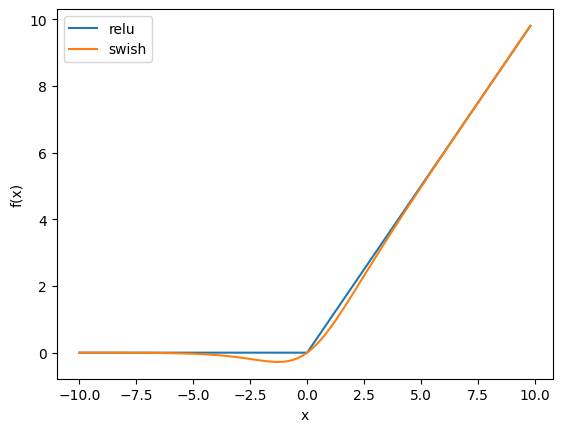

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit

x = np.arange(-10, 10, 0.2) 

plt.plot(x, x.clip(0), label='relu') #양수인 값만 남기는 relu함수적용
plt.plot(x, x * expit(x), label='swish')
#렐루함수와 달리 약간의 음수를 허용하고 성능이 더 우수하다 

plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()

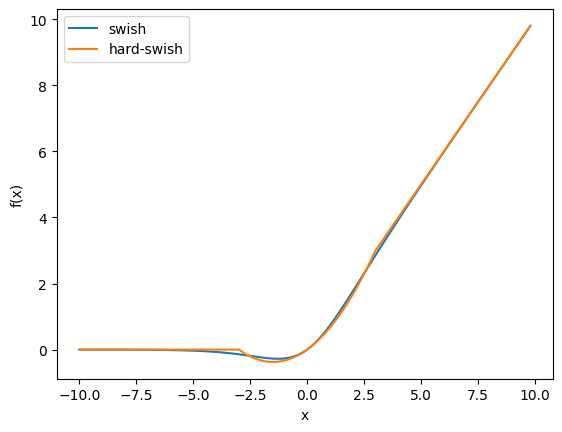

In [17]:
def relu6(x):
    return np.minimum(np.maximum(x, 0), 6)

x = np.arange(-10, 10, 0.2)

plt.plot(x, x * expit(x), label='swish')

plt.plot(x, x * relu6(x+3)/6, label='hard-swish') #시그모이드는 x=-3 근처에서 0에 가깝고, x=3 근처에서 1에 가깝습니다. 이 구간을 직선으로 근사한 것이 ReLU6(x+3)/6 입니다.

plt.xlabel('x')

plt.ylabel('f(x)')

plt.legend()

plt.show()

#### 역 잔차 블록 만들기¶

In [18]:
def inv_res_block(inputs, filters_out, kernel_size, strides, dropout_rate, expand_ratio):
    # 팽창 단계
    filters_in = inputs.shape[-1] #입력의 채널 수를 가져옵니다 
    filters = filters_in * expand_ratio #채널을 expand_ratio만큼 팽창시킨다
    if expand_ratio > 1:
        x = layers.Conv2D(filters, 1, padding='same', use_bias=False)(inputs) #채널만 늘리고 공간 크기는 유지
        x = layers.BatchNormalization()(x)
        x = layers.Activation('swish')(x)
    else:
        x = inputs


        

    # 깊이별 분리 합성곱
    if strides == 2:
        x = layers.ZeroPadding2D(padding=padding_size(x.shape, kernel_size))(x) #strides=2일 때 ZeroPadding을 먼저 적용하여 크기를 맞춥니다
    x = layers.DepthwiseConv2D(kernel_size, strides=strides, use_bias=False, #채널별로 독립적으로 합성곱 수행
                               padding='same' if strides == 1 else 'valid')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)

    # SE 블록
    se_input = x
    x = layers.GlobalAveragePooling2D(keepdims=True)(x) #공간정보를 평균낸다
    x = layers.Conv2D(int(filters_in * 0.25), 1, padding='same', activation='swish')(x) #채널을 25%로 줄여 병목생성
    x = layers.Conv2D(filters, 1, padding='same', activation='sigmoid')(x) #다시 원래 채널 수로 복원
    x = layers.Multiply()([se_input, x])

    # 출력 단계
    x = layers.Conv2D(filters_out, 1, padding='same', use_bias=False)(x) #1x1합성곱으로 목표 채널 수로 축소 
    x = layers.BatchNormalization()(x)
    if strides == 1 and filters_in == filters_out:
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate, noise_shape=(None, 1, 1, 1))(x) #채널 단위로 드롭아웃
            x = layers.Add()([x, inputs])
    return x

In [19]:
def padding_size(input_size, kernel_size):
    # 입력 크기가 짝수이면 위쪽과 왼쪽 패딩을 하나 줄입니다.
    padding = kernel_size // 2
    #커널 크기의 절반을 기본 패딩으로 설정합니다
    
    if input_size[1] % 2 == 0:
    #입력의 높이를 의미합니다
        return ((padding - 1, padding),
                (padding - 1, padding))
    else:
        return padding

In [20]:
import math

def round_repeats(repeats, depth):
    """repeats * depth 보다 큰 정수를 반환합니다"""
    return int(math.ceil(repeats * depth)) #올림함수이다

def round_filters(filters, width):
    """filters * width 보다 크고 8의 배수가 되도록 만듭니다"""
    filters *= width #기본채널에 width를 곱해 목표채널수를 구한다
    new_filters = max(8, int(filters + 4) // 8 * 8)
    #8의 배수로 반올림을한다.
    
    if new_filters < 0.9 * filters: #너무 작아질 경우 8을 추가로 더해 손실을 방지 한다.  8또는 16이 가장 좋기에 8의배수
        new_filters += 8
    return int(new_filters)

#### EfficientNet 모델 만들기

In [21]:
import keras
from keras import layers

In [22]:
width = 1.0
depth = 1.0
inputs = layers.Input(shape=(224, 224, 3))

x = layers.Rescaling(1.0 / 255.0)(inputs) #정규화
x = layers.Normalization()(x) # 평균을 0으로 맞춘다
x = layers.Rescaling(1.0 / np.sqrt([0.229, 0.224, 0.225]))(x) #표준편차로 나누어 분산을 1로맞춘다.


x = layers.ZeroPadding2D(padding=padding_size(x.shape, 3))(x) #첫번째합성곱 32채널출력
x = layers.Conv2D(round_filters(32, width), 3, strides=2, padding='valid', use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('swish')(x)

In [23]:
blocks_params = [
    {
        "kernel_size": 3, 
        "repeats": 1,
        "filters_out": 16,
        "strides": 1 #유지
    },
    {
        "kernel_size": 3,
        "repeats": 2,
        "filters_out": 24,
        "strides": 2 #절반
    },
    {
        "kernel_size": 5,
        "repeats": 2,
        "filters_out": 40,
        "strides": 2 #절반
    },
    {
        "kernel_size": 3,
        "repeats": 3,
        "filters_out": 80,
        "strides": 2 #절반
    },
    {
        "kernel_size": 5,
        "repeats": 3,
        "filters_out": 112,
        "strides": 1 #유지
    },
    {
        "kernel_size": 5,
        "repeats": 4,
        "filters_out": 192,
        "strides": 2 #절반
    },
    {
        "kernel_size": 3,
        "repeats": 1,
        "filters_out": 320,
        "strides": 1 #유지
    },
]

In [24]:
filter_expand_ratio = 1 #첫스테이지만 바로시작
block_count = 0
total_blocks = float(sum(round_repeats(params["repeats"], depth) for params in blocks_params))
#전체 블록수를 미리계산 

for params in blocks_params:
    # depth에 따라 블록의 입력과 출력 필터를 늘립니다.
    filters_out = round_filters(params['filters_out'], width)
    strides = params["strides"]
    for j in range(round_repeats(params["repeats"], depth)):
        # 반복의 첫 번째 블록을 제외한 나머지 블록은 스트라이드 1입니다.
        if j > 0:
            strides = 1
        dropout_rate = 0.2 * block_count / total_blocks
        #드롭아웃이 뒤로갈수록 강해진다
        
        x = inv_res_block(x, filters_out, params['kernel_size'],
                          strides, dropout_rate, filter_expand_ratio)
        block_count += 1
    filter_expand_ratio = 6
    #팽창비율 변경

In [25]:
x = layers.Conv2D(round_filters(1280, width), 1, padding='same', use_bias=False)(x)
#특징확장

x = layers.BatchNormalization()(x)
x = layers.Activation('swish')(x)

x = layers.GlobalAveragePooling2D()(x)
#공간압축

x = layers.Dropout(0.2)(x)
#과적합방지

outputs = layers.Dense(1000, activation='softmax')(x)
#클래스분류
model = keras.Model(inputs, outputs)

In [26]:
model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_5 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, 224, 224, 3)          0         ['input_5[0][0]']             
                                                                                                  
 normalization (Normalizati  (None, 224, 224, 3)          7         ['rescaling[0][0]']           
 on)                                                                                              
                                                                                                  
 rescaling_1 (Rescaling)     (None, 224, 224, 3)          0         ['normalization[0][0]'] 

#### EfficientNet 모델로 강아지 사진 분류하기

In [27]:
import numpy as np
from PIL import Image

dog_png = np.array(Image.open('images/dog.png'))

In [28]:
from keras.applications import efficientnet

efficientb0 = keras.applications.EfficientNetB0()
predictions = efficientb0.predict(dog_png[np.newaxis,:])
efficientnet.decode_predictions(predictions)

21834768/21834768 [==============================] - 1s 0us/step


2026-04-16 09:41:34.592575: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


1/1 [==============================] - 1s 984ms/step


[[('n02099712', 'Labrador_retriever', 0.3682946),
  ('n02104029', 'kuvasz', 0.19339834),
  ('n02099601', 'golden_retriever', 0.06145826),
  ('n02111500', 'Great_Pyrenees', 0.057796918),
  ('n02095889', 'Sealyham_terrier', 0.017902788)]]